# Roteiro de Aula: Aprendizado Supervisionado e Não Supervisionado com imóveis

Este notebook orienta um laboratório integrado de Machine Learning usando `dataset_imoveis.csv`. A prática percorre classificação, regressão e agrupamento, relacionando os modelos aos conceitos teóricos da Unidade 3.

O conjunto de dados representa imóveis de diferentes regiões, tipos e características físicas. O objetivo é trabalhar um problema genérico de modelagem, sem depender de uma aplicação específica do mercado financeiro.

## Objetivos
- Diferenciar classificação, regressão e agrupamento.
- Explorar uma base realista com dados numéricos, categóricos e ausentes.
- Construir pré-processamento sem vazamento de dados.
- Comparar modelos de classificação e regressão.
- Interpretar underfitting, overfitting e o efeito da complexidade da árvore.
- Usar K-Means, agrupamento hierárquico e DBSCAN.
- Avaliar modelos supervisionados e a qualidade dos clusters.

## 1. Carregamento e inspeção inicial
1. Importe `pandas`, `numpy`, `matplotlib` e `seaborn`.
2. Carregue `dataset_imoveis.csv` em `df`.
3. Exiba dimensões, tipos, primeiras linhas e quantidade de nulos.
4. Identifique as variáveis que podem ser usadas como atributos e como alvos.

### Perguntas
- Qual é a diferença entre `preco_reais` e `faixa_preco`?
- Quais variáveis são numéricas e quais são categóricas?
- Por que não devemos usar o preço como entrada ao prever a faixa de preço?

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
df = pd.read_csv('dataset_imoveis.csv')

# Inspecao inicial
print('Shape:', df.shape)
display(df.head())
print('Tipos:')
print(df.dtypes)
print('Nulos:')
display(df.isnull().sum().sort_values(ascending=False))

Shape: (500, 9)


,regiao,tipo_imovel,area_m2,quartos,vagas_garagem,idade_imovel_anos,distancia_centro_km,preco_reais,faixa_preco
0,Sul,Casa,127.1,4.0,1,27.0,1.40,494143.0,Médio
1,Oeste,Casa,66.6,2.0,3,5.0,9.31,260799.0,Econômico
2,Leste,Apartamento,135.2,3.0,3,28.0,18.93,451451.0,Médio
3,Leste,Sobrado,144.4,2.0,0,16.0,0.50,518875.0,Médio
4,Norte,Casa,142.4,4.0,2,15.0,13.25,444672.0,Médio


Tipos:
regiao                  object
tipo_imovel             object
area_m2                float64
quartos                float64
vagas_garagem            int64
idade_imovel_anos      float64
distancia_centro_km    float64
preco_reais            float64
faixa_preco             object
dtype: object
Nulos:


,0
preco_reais,37
faixa_preco,37
idade_imovel_anos,12
area_m2,10
tipo_imovel,10
regiao,8
quartos,8
vagas_garagem,0
distancia_centro_km,0


## 2. Análise exploratória
1. Examine estatísticas descritivas das variáveis numéricas.
2. Observe a distribuição do preço e a frequência das faixas.
3. Visualize relações entre área, distância do centro e preço.
4. Verifique se há indícios de classes desbalanceadas.

### Perguntas
- A variável `preco_reais` parece ter valores extremos?
- A distribuição das faixas é equilibrada?
- Uma relação visual forte é suficiente para afirmar que uma variável é causal?

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
regiao,492,4,Norte,130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_imovel,490,3,Apartamento,214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_m2,490.0,NaN,NaN,NaN,124.568776,39.176133,30.0,97.725,125.0,148.375,223.2
quartos,492.0,NaN,NaN,NaN,2.806911,1.031733,1.0,2.0,3.0,3.0,5.0
vagas_garagem,500.0,NaN,NaN,NaN,1.3,0.876091,0.0,1.0,1.0,2.0,3.0
idade_imovel_anos,488.0,NaN,NaN,NaN,20.45082,11.28689,0.0,11.0,20.0,30.0,39.0
distancia_centro_km,500.0,NaN,NaN,NaN,9.41972,9.37799,0.5,2.7225,6.935,11.9925,50.0
preco_reais,463.0,NaN,NaN,NaN,419273.902808,147333.960392,80000.0,320675.0,431603.0,509280.5,851277.0
faixa_preco,463,3,Médio,314,NaN,NaN,NaN,NaN,NaN,NaN,NaN


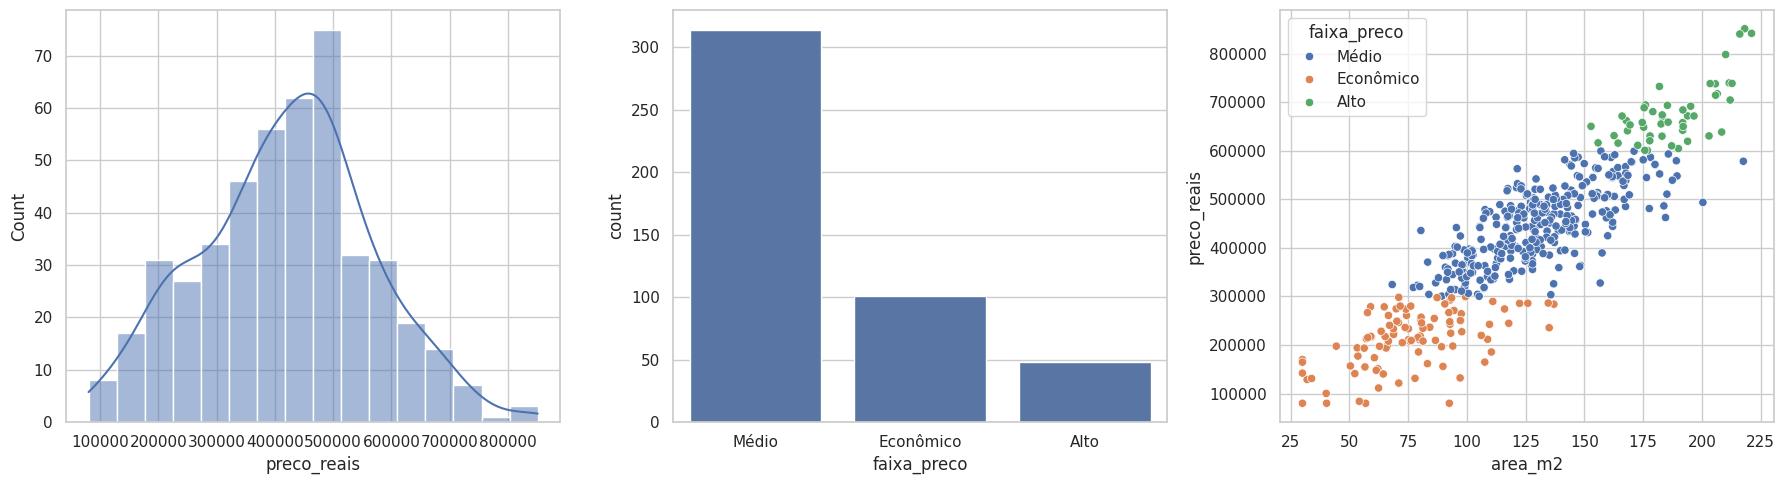

In [9]:
display(df.describe(include='all').T)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=df, x='preco_reais', kde=True, ax=axes[0])
sns.countplot(data=df, x='faixa_preco', ax=axes[1])
sns.scatterplot(data=df, x='area_m2', y='preco_reais', hue='faixa_preco', ax=axes[2])
plt.tight_layout()
plt.show()

## 3. Preparação das tarefas e divisão dos dados
Serão construídas três tarefas:

- **Classificação:** prever `faixa_preco`.
- **Regressão:** prever `preco_reais`.
- **Agrupamento:** encontrar perfis de imóveis sem usar rótulos.

Para classificação e regressão, remova os registros sem alvo. Divida treino e teste antes de ajustar imputadores, codificadores ou escaladores.

In [10]:
from sklearn.model_selection import train_test_split

features = [
    'regiao', 'tipo_imovel', 'area_m2', 'quartos',
    'vagas_garagem', 'idade_imovel_anos', 'distancia_centro_km'
]

df_class = df.dropna(subset=['faixa_preco']).copy()
df_reg = df.dropna(subset=['preco_reais']).copy()

X_class = df_class[features]
y_class = df_class['faixa_preco']
X_reg = df_reg[features]
y_reg = df_reg['preco_reais']

# Divisao treino/teste antes de ajustar qualquer etapa de pre-processamento.
# A estratificacao preserva aproximadamente a proporcao das classes no treino e teste.
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.20, random_state=42, stratify=y_class
)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

print('Registros de classificacao:', len(df_class))
print('Treino classificacao:', X_class_train.shape, '| Teste:', X_class_test.shape)
print('Registros de regressao:', len(df_reg))
print('Treino regressao:', X_reg_train.shape, '| Teste:', X_reg_test.shape)


Registros de classificacao: 463
Treino classificacao: (370, 7) | Teste: (93, 7)
Registros de regressao: 463
Treino regressao: (370, 7) | Teste: (93, 7)


## 4. EDA automatizada com `ydata-profiling`

1. Instale `ydata-profiling` no ambiente do notebook, se necessário.
2. Gere um relatório exploratório usando somente o conjunto de treino da classificação.
3. Examine estatísticas, valores ausentes, distribuições, correlações e alertas de qualidade.
4. Não use o conjunto de teste para decidir imputação, encoding, escala ou modelo.

### Documentação
- [Documentação do ydata-profiling](https://docs.profiling.ydata.ai/latest/)
- [ProfileReport](https://docs.profiling.ydata.ai/latest/features/advanced_usage/)

### Perguntas
- Por que o relatório deve ser gerado a partir do treino em uma tarefa supervisionada?
- Quais achados do relatório podem orientar o pré-processamento?
- Um alerta de correlação implica que uma variável deve ser removida automaticamente?

In [11]:
# Instale o pacote no ambiente do notebook, se necessario:
%pip install -q ydata-profiling

from ydata_profiling import ProfileReport

# O profiling supervisionado usa somente o conjunto de treino.
df_class_train = X_class_train.copy()
df_class_train['faixa_preco'] = y_class_train.values

profile = ProfileReport(
    df_class_train,
    title='EDA - treino de classificacao',
    minimal=True
)

# Salva uma copia para consulta posterior.
profile.to_file('relatorio_eda_treino.html')

# Em ambientes Jupyter, a linha abaixo abre o relatorio no notebook:
profile.to_notebook_iframe()

print('Relatorio salvo em: relatorio_eda_treino.html')
print('O teste nao foi utilizado para definir imputacao, encoding, escala ou modelo.')


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 84.89it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Relatorio salvo em: relatorio_eda_treino.html
O teste nao foi utilizado para definir imputacao, encoding, escala ou modelo.


## 5. Pré-processamento sem vazamento
1. Crie uma funcao que devolva um novo `ColumnTransformer` para cada tarefa.
2. Ajuste o pre-processador de classificacao somente em `X_class_train`.
3. Ajuste o pre-processador de regressao somente em `X_reg_train`.
4. Transforme os respectivos conjuntos de teste sem chamar `fit` neles.
5. Para agrupamento exploratorio, use um pre-processador separado e deixe claro que ele nao participa da avaliacao supervisionada.

### Checklist de boas práticas
- A remocao de linhas sem alvo ocorre antes da divisao, pois nao e imputacao de atributo.
- Nenhuma estatistica do teste deve definir mediana, moda, categorias ou escala.
- O conjunto de teste deve ser usado somente para medir o desempenho final.
- Nao use `preco_reais` nem `faixa_preco` como atributo de classificacao ou agrupamento.

### Perguntas
- Por que usar objetos de pre-processamento separados evita reutilizar estado entre tarefas?
- Qual e a diferenca entre `fit_transform` no treino e `transform` no teste?
- Por que o pre-processamento do agrupamento nao deve ser avaliado com acuracia?

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    'area_m2', 'quartos', 'vagas_garagem',
    'idade_imovel_anos', 'distancia_centro_km'
]
categorical_features = ['regiao', 'tipo_imovel']

def build_preprocessor():
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Cada tarefa recebe um pre-processador independente.
preprocessor_class = build_preprocessor()
preprocessor_reg = build_preprocessor()

# Ajuste exclusivamente no treino; no teste apenas transformacao.
X_class_train_prep = preprocessor_class.fit_transform(X_class_train)
X_class_test_prep = preprocessor_class.transform(X_class_test)

X_reg_train_prep = preprocessor_reg.fit_transform(X_reg_train)
X_reg_test_prep = preprocessor_reg.transform(X_reg_test)

print('Classificacao - treino preparado:', X_class_train_prep.shape)
print('Classificacao - teste preparado:', X_class_test_prep.shape)
print('Regressao - treino preparado:', X_reg_train_prep.shape)
print('Regressao - teste preparado:', X_reg_test_prep.shape)


Classificacao - treino preparado: (370, 12)
Classificacao - teste preparado: (93, 12)
Regressao - treino preparado: (370, 12)
Regressao - teste preparado: (93, 12)


## 5. Classificação: comparação de modelos
Compare pelo menos três modelos:

- Regressão Logística;
- KNN;
- Árvore de Decisão.

Calcule acurácia e F1 macro. Para a árvore, experimente diferentes valores de `max_depth`. Exiba a matriz de confusão do melhor modelo.

### Perguntas
- O modelo com maior acurácia também possui maior F1 macro?
- O que uma árvore muito profunda pode indicar?
- Como o valor de `k` afeta o KNN?

,modelo,acuracia,f1_macro
0,Regressao Logistica,0.9247,0.9017
1,Arvore (prof=8),0.8710,0.8336
2,Arvore (sem limite),0.8710,0.8336
3,KNN (k=5),0.8817,0.8192
4,Arvore (prof=3),0.8065,0.7904


Melhor modelo por F1 macro: Regressao Logistica

Relatorio de classificacao:
              precision    recall  f1-score   support

        Alto       0.82      0.90      0.86        10
   Econômico       0.86      0.95      0.90        20
       Médio       0.97      0.92      0.94        63

    accuracy                           0.92        93
   macro avg       0.88      0.92      0.90        93
weighted avg       0.93      0.92      0.93        93



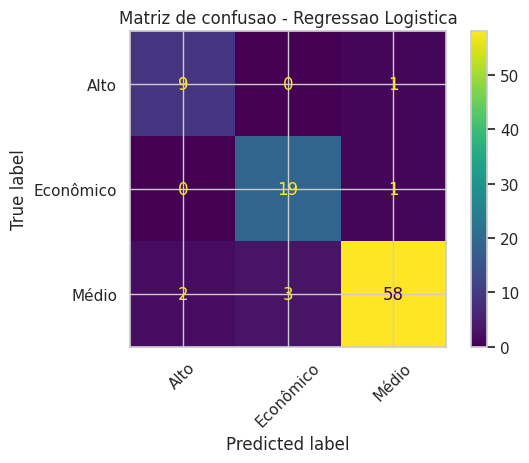

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

modelos_class = {
    'Regressao Logistica': LogisticRegression(max_iter=2000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Arvore (prof=3)': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Arvore (prof=8)': DecisionTreeClassifier(max_depth=8, random_state=42),
    'Arvore (sem limite)': DecisionTreeClassifier(random_state=42)
}

resultados_class = []
modelos_class_treinados = {}

for nome, modelo in modelos_class.items():
    modelo.fit(X_class_train_prep, y_class_train)
    pred = modelo.predict(X_class_test_prep)
    acc = accuracy_score(y_class_test, pred)
    f1 = f1_score(y_class_test, pred, average='macro')
    resultados_class.append({
        'modelo': nome,
        'acuracia': acc,
        'f1_macro': f1
    })
    modelos_class_treinados[nome] = modelo

resultados_class_df = (
    pd.DataFrame(resultados_class)
    .sort_values(['f1_macro', 'acuracia'], ascending=False)
    .reset_index(drop=True)
)

display(resultados_class_df.style.format({
    'acuracia': '{:.4f}',
    'f1_macro': '{:.4f}'
}))

melhor_class_nome = resultados_class_df.loc[0, 'modelo']
melhor_class_modelo = modelos_class_treinados[melhor_class_nome]
melhor_class_pred = melhor_class_modelo.predict(X_class_test_prep)

print('Melhor modelo por F1 macro:', melhor_class_nome)
print('\nRelatorio de classificacao:')
print(classification_report(y_class_test, melhor_class_pred))

ConfusionMatrixDisplay.from_predictions(
    y_class_test,
    melhor_class_pred,
    xticks_rotation=45
)
plt.title(f'Matriz de confusao - {melhor_class_nome}')
plt.tight_layout()
plt.show()


## 6. Regressão: linearidade e regularização
Compare Regressão Linear, Ridge e Lasso. Use MAE, RMSE e R².

### Perguntas
- Qual modelo apresenta menor erro no teste?
- A regularização mudou o desempenho ou a estabilidade?
- Um R² alto significa necessariamente que o modelo é útil?

In [14]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Os dados de regressao ja foram preparados usando um pre-processador
# ajustado exclusivamente em X_reg_train.
modelos_reg = {
    'Regressao Linear': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Lasso (alpha=0.01)': Lasso(alpha=0.01, max_iter=10000)
}

resultados_reg = []
modelos_reg_treinados = {}

for nome, modelo in modelos_reg.items():
    modelo.fit(X_reg_train_prep, y_reg_train)
    pred = modelo.predict(X_reg_test_prep)

    mae = mean_absolute_error(y_reg_test, pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, pred))
    r2 = r2_score(y_reg_test, pred)

    resultados_reg.append({
        'modelo': nome,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })
    modelos_reg_treinados[nome] = modelo

resultados_reg_df = (
    pd.DataFrame(resultados_reg)
    .sort_values('MAE', ascending=True)
    .reset_index(drop=True)
)

display(resultados_reg_df.style.format({
    'MAE': '{:,.2f}',
    'RMSE': '{:,.2f}',
    'R2': '{:.4f}'
}))

melhor_reg_nome = resultados_reg_df.loc[0, 'modelo']
print('Melhor modelo por menor MAE no teste:', melhor_reg_nome)


,modelo,MAE,RMSE,R2
0,Regressao Linear,"17,207.61","21,226.05",0.9775
1,Lasso (alpha=0.01),"17,207.62","21,226.06",0.9775
2,Ridge (alpha=1.0),"17,267.11","21,287.48",0.9774


Melhor modelo por menor MAE no teste: Regressao Linear


## 7. Regressão: complexidade da árvore
Treine árvores de decisão com `max_depth=3`, `max_depth=8` e sem limite. Compare os erros de treino e teste.

### Perguntas
- Em que situação a diferença entre treino e teste sugere overfitting?
- O que acontece quando a árvore fica mais complexa?
- Qual profundidade parece produzir melhor equilíbrio?

,max_depth,MAE_treino,MAE_teste,RMSE_treino,RMSE_teste,R2_treino,R2_teste
0,3,"45,981.64","54,145.74","58,115.53","67,037.05",0.8463,0.7756
1,8,"10,053.86","48,620.31","16,121.81","60,615.45",0.9882,0.8165
2,sem limite,0.00,"51,207.08",0.00,"64,130.95",1.0000,0.7947


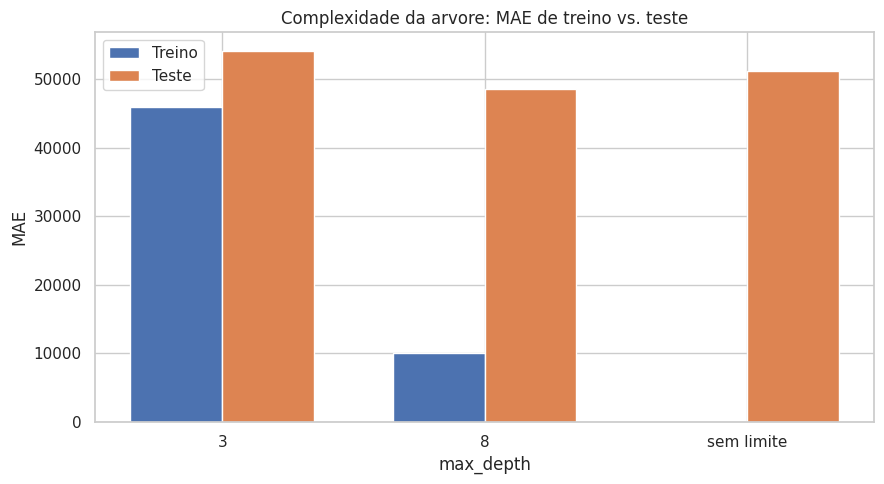

Uma grande queda do MAE no treino acompanhada por MAE maior no teste e um sinal de overfitting.


In [15]:
from sklearn.tree import DecisionTreeRegressor

profundidades = [3, 8, None]
resultados_arvore_reg = []

for profundidade in profundidades:
    modelo = DecisionTreeRegressor(max_depth=profundidade, random_state=42)
    modelo.fit(X_reg_train_prep, y_reg_train)

    pred_treino = modelo.predict(X_reg_train_prep)
    pred_teste = modelo.predict(X_reg_test_prep)

    resultados_arvore_reg.append({
        'max_depth': 'sem limite' if profundidade is None else profundidade,
        'MAE_treino': mean_absolute_error(y_reg_train, pred_treino),
        'MAE_teste': mean_absolute_error(y_reg_test, pred_teste),
        'RMSE_treino': np.sqrt(mean_squared_error(y_reg_train, pred_treino)),
        'RMSE_teste': np.sqrt(mean_squared_error(y_reg_test, pred_teste)),
        'R2_treino': r2_score(y_reg_train, pred_treino),
        'R2_teste': r2_score(y_reg_test, pred_teste)
    })

resultados_arvore_reg_df = pd.DataFrame(resultados_arvore_reg)
display(resultados_arvore_reg_df.style.format({
    'MAE_treino': '{:,.2f}',
    'MAE_teste': '{:,.2f}',
    'RMSE_treino': '{:,.2f}',
    'RMSE_teste': '{:,.2f}',
    'R2_treino': '{:.4f}',
    'R2_teste': '{:.4f}'
}))

# Visualizacao simples do MAE para treino e teste.
plt.figure(figsize=(9, 5))
x = np.arange(len(resultados_arvore_reg_df))
largura = 0.35
plt.bar(x - largura/2, resultados_arvore_reg_df['MAE_treino'], largura, label='Treino')
plt.bar(x + largura/2, resultados_arvore_reg_df['MAE_teste'], largura, label='Teste')
plt.xticks(x, resultados_arvore_reg_df['max_depth'])
plt.ylabel('MAE')
plt.xlabel('max_depth')
plt.title('Complexidade da arvore: MAE de treino vs. teste')
plt.legend()
plt.tight_layout()
plt.show()

print('Uma grande queda do MAE no treino acompanhada por MAE maior no teste e um sinal de overfitting.')


## 8. Agrupamento exploratório
Agora ignore `preco_reais` e `faixa_preco`. O objetivo é descobrir perfis de imóveis apenas a partir de suas características.

1. Prepare os dados com imputação, encoding e escala.
2. Use o método do cotovelo para testar `k` entre 2 e 6.
3. Use a silhueta para apoiar a escolha de `k`.
4. Treine K-Means e visualize os grupos com PCA.

### Perguntas
- O cotovelo e a silhueta indicam o mesmo valor de `k`?
- Como interpretar um valor baixo de silhueta?
- O preço pode ser usado depois apenas para descrever os clusters, sem ter participado da formação?

,k,inertia,silhouette
0,2,"2,817.65",0.1150
1,3,"2,539.49",0.1199
2,4,"2,317.65",0.1132
3,5,"2,149.07",0.1176
4,6,"2,017.01",0.1168


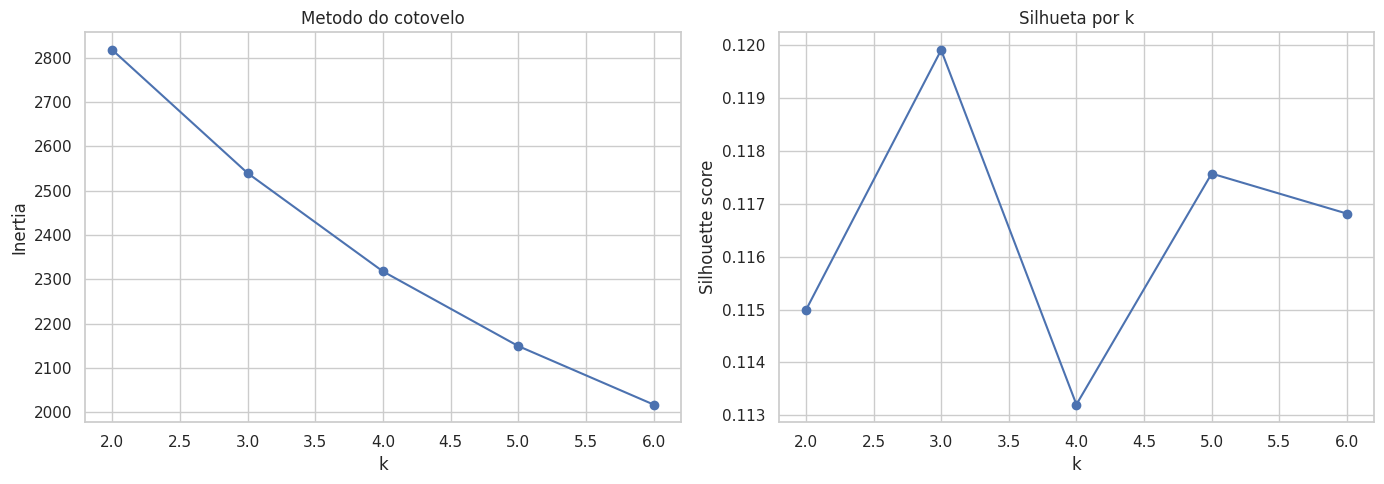

k escolhido pela maior silhueta: 3
Silhueta do K-Means final: 0.1199
Tamanhos dos clusters:
0     63
1    235
2    202
Name: count, dtype: int64


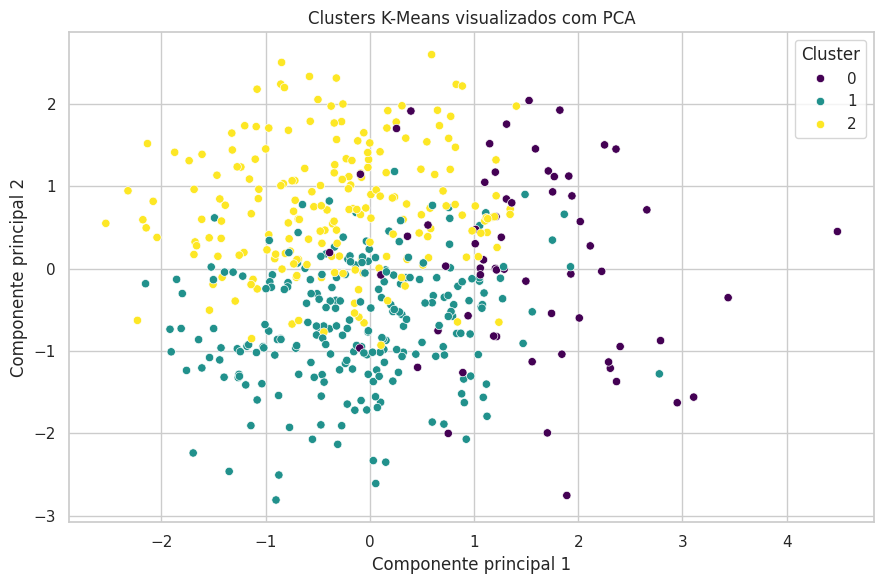

In [16]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# O agrupamento nao usa preco_reais nem faixa_preco.
X_cluster = df[features].copy()

# Pre-processador separado: seu estado nao participa das tarefas supervisionadas.
preprocessor_cluster = build_preprocessor()
X_cluster_prep = preprocessor_cluster.fit_transform(X_cluster)

inertias = []
silhouettes = []
ks = range(2, 7)

for k in ks:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = modelo.fit_predict(X_cluster_prep)
    inertias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(X_cluster_prep, labels))

avaliacao_k = pd.DataFrame({
    'k': list(ks),
    'inertia': inertias,
    'silhouette': silhouettes
})

display(avaliacao_k.style.format({
    'inertia': '{:,.2f}',
    'silhouette': '{:.4f}'
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(ks), inertias, marker='o')
axes[0].set_title('Metodo do cotovelo')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(ks), silhouettes, marker='o')
axes[1].set_title('Silhueta por k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.show()

# Escolha operacional: maior silhueta. O grafico do cotovelo deve ser analisado em conjunto.
k_escolhido = int(avaliacao_k.loc[avaliacao_k['silhouette'].idxmax(), 'k'])
print('k escolhido pela maior silhueta:', k_escolhido)

kmeans = KMeans(n_clusters=k_escolhido, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_cluster_prep)
sil_kmeans = silhouette_score(X_cluster_prep, kmeans_labels)

print(f'Silhueta do K-Means final: {sil_kmeans:.4f}')
print('Tamanhos dos clusters:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

pca_cluster = PCA(n_components=2, random_state=42)
X_cluster_pca = pca_cluster.fit_transform(X_cluster_prep)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_cluster_pca[:, 0],
    y=X_cluster_pca[:, 1],
    hue=kmeans_labels,
    palette='viridis'
)
plt.title('Clusters K-Means visualizados com PCA')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


## 9. Agrupamento hierárquico e DBSCAN
1. Compare o agrupamento hierárquico com o K-Means usando o mesmo `k`.
2. Calcule a silhueta dos dois agrupamentos.
3. Teste DBSCAN com valores diferentes de `eps` e `min_samples`.
4. Conte clusters encontrados e pontos classificados como ruído.

### Perguntas
- Por que o DBSCAN não exige informar `k`?
- O que significa o rótulo `-1`?
- Qual método parece mais adequado à estrutura desta base? Justifique com métricas e visualizações.

Silhueta K-Means:       0.1199
Silhueta Hierarquico:   0.0907


,eps,min_samples,clusters,ruido,silhouette_sem_ruido
0,0.500000,5,0,500,N/A
1,0.700000,5,0,500,N/A
2,1.000000,5,1,495,N/A
3,1.200000,5,8,445,0.3690
4,0.700000,10,0,500,N/A
5,1.000000,10,0,500,N/A


Melhor DBSCAN testado: eps=1.2, min_samples=5
Clusters encontrados: 8
Pontos classificados como ruido (-1): 445


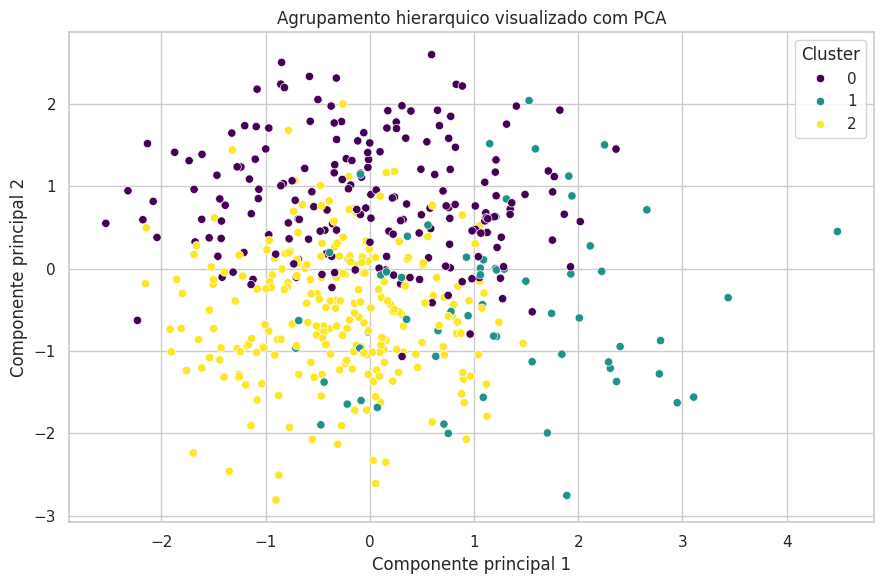

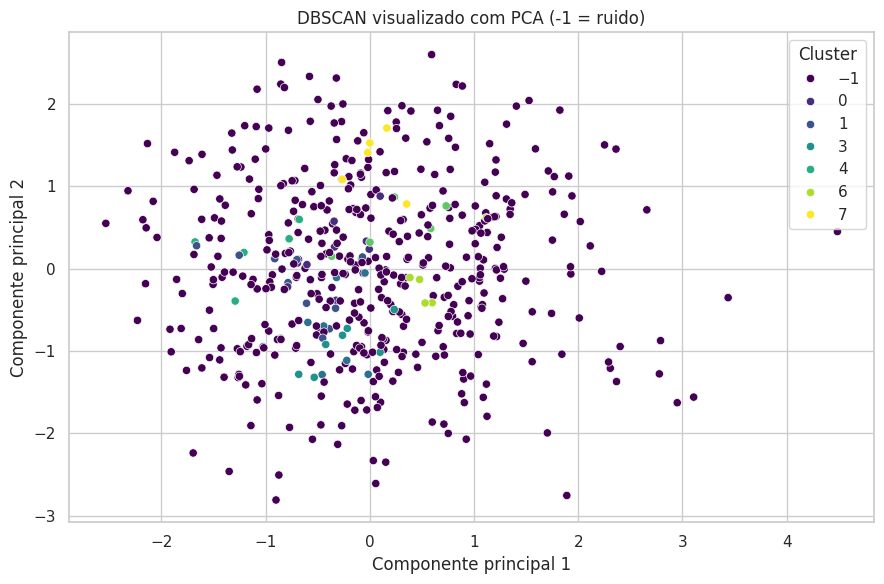

In [17]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN

# Agrupamento hierarquico com o mesmo k do K-Means.
hierarquico = AgglomerativeClustering(n_clusters=k_escolhido)
hier_labels = hierarquico.fit_predict(X_cluster_prep)
sil_hier = silhouette_score(X_cluster_prep, hier_labels)

print(f'Silhueta K-Means:       {sil_kmeans:.4f}')
print(f'Silhueta Hierarquico:   {sil_hier:.4f}')

# DBSCAN nao recebe k. Testamos diferentes combinacoes de eps e min_samples.
parametros_dbscan = [
    (0.5, 5),
    (0.7, 5),
    (1.0, 5),
    (1.2, 5),
    (0.7, 10),
    (1.0, 10)
]

resultados_dbscan = []

for eps, min_samples in parametros_dbscan:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels_db = dbscan.fit_predict(X_cluster_prep)

    n_ruido = int(np.sum(labels_db == -1))
    clusters = set(labels_db) - {-1}
    n_clusters = len(clusters)

    # Silhueta somente quando existem pelo menos 2 clusters e sobra mais de um ponto.
    mask = labels_db != -1
    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil_db = silhouette_score(X_cluster_prep[mask], labels_db[mask])
    else:
        sil_db = np.nan

    resultados_dbscan.append({
        'eps': eps,
        'min_samples': min_samples,
        'clusters': n_clusters,
        'ruido': n_ruido,
        'silhouette_sem_ruido': sil_db
    })

resultados_dbscan_df = pd.DataFrame(resultados_dbscan)
display(resultados_dbscan_df.style.format({
    'silhouette_sem_ruido': lambda x: 'N/A' if pd.isna(x) else f'{x:.4f}'
}))

# Escolhe, entre configuracoes com pelo menos 2 clusters, a maior silhueta.
validos_dbscan = resultados_dbscan_df.dropna(subset=['silhouette_sem_ruido'])
if not validos_dbscan.empty:
    melhor_db = validos_dbscan.loc[validos_dbscan['silhouette_sem_ruido'].idxmax()]
    dbscan_final = DBSCAN(
        eps=float(melhor_db['eps']),
        min_samples=int(melhor_db['min_samples'])
    )
    dbscan_labels = dbscan_final.fit_predict(X_cluster_prep)

    print(
        f"Melhor DBSCAN testado: eps={melhor_db['eps']}, "
        f"min_samples={int(melhor_db['min_samples'])}"
    )
    print(f"Clusters encontrados: {int(melhor_db['clusters'])}")
    print(f"Pontos classificados como ruido (-1): {int(melhor_db['ruido'])}")
else:
    dbscan_labels = None
    print('Nenhuma configuracao do DBSCAN produziu pelo menos dois clusters.')

# Visualizacao do agrupamento hierarquico.
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_cluster_pca[:, 0],
    y=X_cluster_pca[:, 1],
    hue=hier_labels,
    palette='viridis'
)
plt.title('Agrupamento hierarquico visualizado com PCA')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Visualizacao do melhor DBSCAN, se houver.
if dbscan_labels is not None:
    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        x=X_cluster_pca[:, 0],
        y=X_cluster_pca[:, 1],
        hue=dbscan_labels,
        palette='viridis'
    )
    plt.title('DBSCAN visualizado com PCA (-1 = ruido)')
    plt.xlabel('Componente principal 1')
    plt.ylabel('Componente principal 2')
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()


## 10. Visualização final dos clusters com PCA

O PCA (Principal Component Analysis) transforma várias variáveis correlacionadas em novas componentes lineares. A primeira componente captura a maior variância possível, a segunda captura a maior parte restante e assim por diante. A visualização em duas componentes é uma aproximação: ela facilita observar padrões, mas pode esconder informação das dimensões descartadas.

Acesse a documentação antes de executar:
- [Documentação do PCA no scikit-learn](https://scikit-learn.org/stable/modules/decomposition.html#pca)
- [Exemplo oficial de redução de dimensionalidade](https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_iris.html)

### Perguntas
- O que significa reduzir a dimensionalidade de 13 atributos para 2 componentes?
- Qual proporção da variância é explicada pelas duas componentes?
- Um cluster separado no gráfico 2D necessariamente está bem separado no espaço original?

Variancia explicada pela componente 1: 0.1671
Variancia explicada pela componente 2: 0.1658
Variancia explicada pelas duas componentes: 0.3328


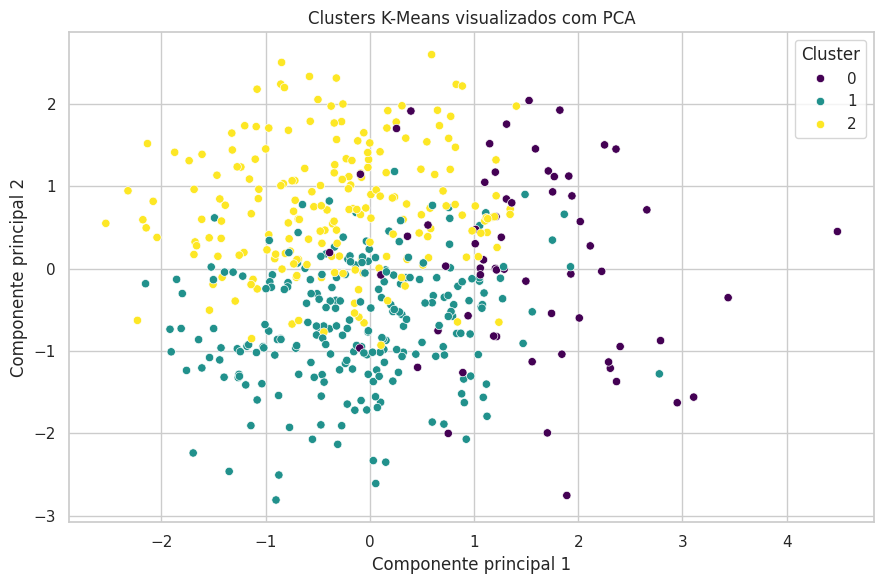


Interpretacao: reduzir a dimensionalidade para 2 componentes permite visualizar uma base com muitas variaveis em um plano. A soma das variancias explicadas indica quanto da variacao total e preservada nessa projecao.


In [18]:
from sklearn.decomposition import PCA

# O PCA e usado aqui somente para visualizacao, nao para treinar os modelos.
pca = PCA(n_components=2, random_state=42)
X_cluster_pca = pca.fit_transform(X_cluster_prep)

variancias = pca.explained_variance_ratio_
print('Variancia explicada pela componente 1:', f'{variancias[0]:.4f}')
print('Variancia explicada pela componente 2:', f'{variancias[1]:.4f}')
print('Variancia explicada pelas duas componentes:', f'{variancias.sum():.4f}')

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_cluster_pca[:, 0],
    y=X_cluster_pca[:, 1],
    hue=kmeans_labels,
    palette='viridis'
)
plt.title('Clusters K-Means visualizados com PCA')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print(
    '\nInterpretacao: reduzir a dimensionalidade para 2 componentes permite '
    'visualizar uma base com muitas variaveis em um plano. A soma das variancias '
    'explicadas indica quanto da variacao total e preservada nessa projecao.'
)


## 11. Conclusão
Claro. Dá para deixar bem mais simples, mantendo tudo o que foi pedido:

### 11.1 Classificação

* Informe o **melhor modelo**, usando o maior **F1 macro**.
* Compare com a **acurácia**.
* Diga se as duas métricas escolheram o mesmo modelo.
* Explique quais classes mais confundiram na matriz de confusão.

### 11.2 Regressão

* Informe o **melhor modelo** entre Linear, Ridge e Lasso, usando o menor **MAE**.
* Coloque **MAE, RMSE e R²**.
* Diga se Ridge ou Lasso melhoraram o resultado de forma significativa.

### 11.3 Complexidade

* Compare as árvores de profundidade **3, 8 e sem limite**.
* Explique:

  * **Underfitting:** modelo ruim no treino e no teste.
  * **Overfitting:** modelo muito bom no treino, mas pior no teste.
* Indique qual profundidade teve o melhor equilíbrio.

### 11.4 Agrupamento

* Informe o **k escolhido** e a **silhueta do K-Means**.
* Diga se o **cotovelo e a silhueta** indicam o mesmo k.
* Compare K-Means com o **agrupamento hierárquico**.
* No **DBSCAN**, informe:

  * `eps`
  * `min_samples`
  * número de clusters
  * número de pontos de ruído.

### 11.5 PCA

* Informe a **variância explicada pelas 2 componentes**.
* Explique que uma boa separação no gráfico 2D **não garante** uma boa separação nos dados originais.

### 11.6 Limitações e melhorias

Comente rapidamente:

* tamanho da amostra;
* valores extremos e qualidade dos dados;
* escolha dos parâmetros;
* uso de validação cruzada;
* possibilidade de testar outros modelos e métricas;
* os clusters devem ser formados **sem usar `preco_reais` ou `faixa_preco`**.

### Síntese final

Faça um pequeno parágrafo resumindo os resultados de **classificação, regressão e agrupamento**.

Lembre:

* **Supervisionado:** classificação e regressão → possuem um alvo conhecido.
* **Não supervisionado:** agrupamento → não possui alvo conhecido.

Assim, depois de executar o notebook, você só precisa **preencher os resultados e escrever comentários curtos** em cada seção.
